### workflow 정상컴파일 확인

In [ ]:
from AutoHPO.Interface.interface import analysis_experiment_savefile
from pathlib import Path

save_path = Path('./output')

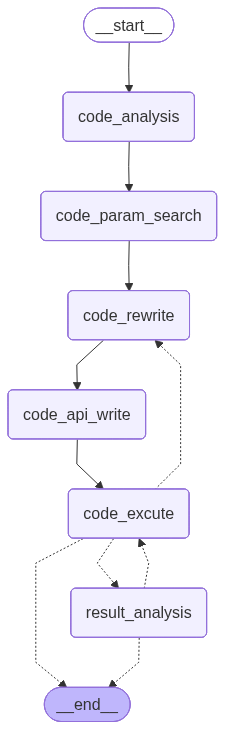

In [4]:
import AutoHPO.Nodes as Nodes 
from AutoHPO.Instance.container import Container
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import END, StateGraph, START
import os


# def finish_HPO(container : Container) -> Container:

    

def route_after_exec(container : Container) -> str:
    rewriteNodeCode = container.get("rewriteNodeCode")
    repairNum = container.get("repairNum")
    repairMaxTries = container.get("repairMaxTries")


    if repairNum <  repairMaxTries:
        if rewriteNodeCode == 0:
            return "result_analysis"
        elif rewriteNodeCode == 1 or rewriteNodeCode == 2:
            if rewriteNodeCode == 1:
                print("런타임 에러, 재작성")
            elif rewriteNodeCode == 2:
                print("파일 시스템 불일치, 재작성")
            return "code_rewrite"
        else:
            print("invalid rewrite number")
            return END
    else:
        print("리페어 횟수초과")
        return END



def route_after_analyisis(container : Container):
    max_finetuning_tries = container.get("maxFineTuningTries")
    finetuning_try_num = container.get("fineTuningTrieNum")
    
    if finetuning_try_num < max_finetuning_tries:
        return "code_excute"
    else:
        return END
    

##### 노드 정의 ##### 
workflow = StateGraph(Container)
workflow.add_node("code_analysis", Nodes.code_analysis)
workflow.add_node("code_param_search", Nodes.code_param_search)
workflow.add_node("code_rewrite", Nodes.code_rewrite)
workflow.add_node("code_api_write", Nodes.code_api_write)
workflow.add_node("code_excute", Nodes.code_excute)
workflow.add_node("result_analysis", Nodes.result_analysis)


##### 워크플로우 정의 ##### 
workflow.add_edge(START, "code_analysis")
workflow.add_edge("code_analysis", "code_param_search")
workflow.add_edge("code_param_search", "code_rewrite")
workflow.add_edge("code_rewrite", "code_api_write")
workflow.add_edge("code_api_write", "code_excute")
workflow.add_conditional_edges(
    "code_excute",
    route_after_exec,
    {"code_rewrite": "code_rewrite", "result_analysis": "result_analysis", END:END},
)
workflow.add_conditional_edges(
    "result_analysis",
    route_after_analyisis,
    {END : END, "code_excute": "code_excute"},
)
app = workflow.compile()
app

### 각노드 정상작동 확인

In [5]:
from AutoHPO.Instance.container import Container, make_container
from pathlib import Path

container = make_container()
container["sourceCodePath"] = Path("./target_titanic.py")
container["userRequirements"] = "훈련 데이터랑 검증 데이터를 분리하는 비율도 실험 파라미터의 일부로 쓰고싶다."
container["condaEnv"] = "machine_learning"
container["repairMaxTries"] = 2
container["fineTuningTrieNum"] = 2
container

{'sourceCodePath': PosixPath('target_titanic.py'),
 'pythonEnv': PosixPath('/Users/yujin/anaconda3/envs/AutoFineTuner/bin/python3.10'),
 'savePath': PosixPath('output'),
 'sourceCode': '',
 'refactoredCode': '',
 'userRequirements': '훈련 데이터랑 검증 데이터를 분리하는 비율도 실험 파라미터의 일부로 쓰고싶다.',
 'isML': False,
 'rewriteNodeCode': 0,
 'paramList': [],
 'condaEnv': 'machine_learning',
 'repairMaxTries': 2,
 'maxFineTuningTries': 10,
 'codeAPI': {},
 'repairNum': 0,
 'repairHistroy': [],
 'finetuningHistory': [],
 'lastExcuteResult': {},
 'fineTuningTrieNum': 2}

In [6]:
app.invoke(container)

code_analysis
isML : True
code_param_search
param_list :  ['test_size', 'num_epochs', 'batch_size', 'lr']
code_rewrite
import sys
import os
import json
import time
import datetime
import argparse
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


def _save_model_generic(model, path: Path) -> str:
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        import torch
        torch.save(model.state_dict() if hasattr(model, 'state_dict') else model, path)
    except Exception:
        import pickle
        with open(path, "wb") as f:
            pickle.dump(model, f)
    return str(path)

def _emit_json_line(payload: dict) -> None:
    sys.stdout.write(json.dumps(payload, ensure_ascii=False) + "\n")
    sys.stdout.flush()

def autofinetuner_result() -> dict:
    t0 = time.time()
    parser = argparse.Argume

KeyError: "Input to ChatPromptTemplate is missing variables {'0.1, 0.2, 0.3'}.  Expected: ['0.1, 0.2, 0.3'] Received: []\nNote: if you intended {0.1, 0.2, 0.3} to be part of the string and not a variable, please escape it with double curly braces like: '{{0.1, 0.2, 0.3}}'.\nFor troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_PROMPT_INPUT "

In [ ]:
# def get_latest_excuted_output_path(save_path : Path):
#     '''
#     save_path/
#         {실행시간1}/result.json
#         {실행시간2}/result.json
#         ...
#     위 디렉토리중 가장 최근에 수행된 result.json의 경로를 반환해준다.
#     '''
#     if not save_path.exists() or not save_path.is_dir():
#         return False

#     # output/{timestamp}/ 중 최신 실행폴더 탐색
#     runs = sorted(save_path.glob("*/result.json"), key=os.path.getmtime, reverse=True)
#     if not runs:
#         return False

#     result_path = runs[0]
    
#     return result_path

# result_path = get_latest_excuted_output_path(Path("/Users/yujin/Desktop/코딩shit/python_projects/대회/오픈소스개발자대회/AutoFineTuner_ver3/output"))
# print(result_path)

In [ ]:
# from AutoHPO.Tool.read_write import read_json

# result_data = read_json(result_path)
# print(result_data)

In [ ]:
# # 원하는 해당 프롬프트를 통해 재작성된 파일의 실행결과 저장 파일시스템
# output/
# - 20251014024632/
#     - result.json
#     - model.pt
#     - 20251014024632.log

# # 현재 프롬프트를 통해 작성된 코드의 실행결과 저장 파일시스템
# output/
# - 20251014024632/
#     - 20251014024632.log
# - 2025-10-14_02-46-36/
#     - 2025-10-14_02-46-36.log
#     - result.json
#     - model.pt

In [ ]:
result_path

NameError: name 'result_path' is not defined

In [ ]:
container['codeAPI'] = {
    "env": {
        "CUDA_VISIBLE_DEVICES": None,
        "CONDA_ENV": "machine_learning",
        "PYTHON_ENV_PATH": "/Users/yujin/anaconda3/envs/AutoFineTuner/bin/python3.10",
        "USE_CONDA": True,
        "script": "output.py",
        "arguments": {
            "epochs": 1,
            "batch_size": 1,
            "save_dir": "./output",
            "train_path": "data/train.csv",
            "test_path": "",
            "healthcheck": 0,
            "lr": 0.001,
            "test_size": 0.2
        }
    }
}

In [ ]:
Nodes.code_excute(container=container)

[EXECUTE-API] 실행 스크립트: output.py
[EXECUTE-API] 인자 목록: ['--epochs=1', '--batch_size=1', '--save_dir=./output', '--train_path=data/train.csv', '--healthcheck=0', '--lr=0.001', '--test_size=0.2']
[EXECUTE-API] conda_env=machine_learning, python_env=/Users/yujin/anaconda3/envs/AutoFineTuner/bin/python3.10
실행 명령어 상태 :  ['/Users/yujin/anaconda3/bin/conda', 'run', '--no-capture-output', '-n', 'machine_learning', 'python', 'output.py', '--epochs=1', '--batch_size=1', '--save_dir=./output', '--train_path=data/train.csv', '--healthcheck=0', '--lr=0.001', '--test_size=0.2']
[FILESYSTEM] Consistency check passed ✅
[EXECUTE RESULT] rewriteFlag=0, repairFlag=False


{'sourceCodePath': PosixPath('target_titanic.py'),
 'pythonEnv': PosixPath('/Users/yujin/anaconda3/envs/AutoFineTuner/bin/python3.10'),
 'savePath': PosixPath('output'),
 'sourceCode': '',
 'refactoredCode': '',
 'userRequirements': '훈련 데이터랑 검증 데이터를 분리하는 비율도 실험 파라미터의 일부로 쓰고싶다.',
 'isML': False,
 'rewriteNodeCode': 0,
 'paramList': [],
 'condaEnv': 'machine_learning',
 'repairMaxTries': 3,
 'maxFineTuningTries': 10,
 'codeAPI': {'env': {'CUDA_VISIBLE_DEVICES': None,
   'CONDA_ENV': 'machine_learning',
   'PYTHON_ENV_PATH': '/Users/yujin/anaconda3/envs/AutoFineTuner/bin/python3.10',
   'USE_CONDA': True,
   'script': 'output.py',
   'arguments': {'epochs': 1,
    'batch_size': 1,
    'save_dir': './output',
    'train_path': 'data/train.csv',
    'test_path': '',
    'healthcheck': 0,
    'lr': 0.001,
    'test_size': 0.2}}},
 'repairNum': 0,
 'repairHistroy': [],
 'finetuningHistory': [],
 'repairFlag': False,
 'rewriteFlag': 0}

In [ ]:
# class AutoHPO:
#     def __init__(self):
#         workflow = get_workflow()
#         container = make_container()

#     def manage_rewrite_history():
#         ...

#     def 

# def get_workflow():
#     ##### 노드 정의 ##### 
#     workflow = StateGraph(Container)
#     workflow.add_node("code_analysis", Nodes.code_analysis)
#     workflow.add_node("code_param_search", Nodes.code_param_search)
#     workflow.add_node("code_rewrite", Nodes.code_rewrite)
#     workflow.add_node("code_api_write", Nodes.code_api_write)
#     workflow.add_node("code_excute", Nodes.code_excute)
#     workflow.add_node("result_analysis", Nodes.result_analysis)


#     ##### 워크플로우 정의 ##### 
#     workflow.add_edge(START, "code_analysis")
#     workflow.add_edge("code_analysis", "code_param_search")
#     workflow.add_edge("code_param_search", "code_rewrite")
#     workflow.add_edge("code_rewrite", "code_api_write")
#     workflow.add_edge("code_api_write", "code_excute")
#     workflow.add_conditional_edges(
#         "code_excute",
#         route_after_exec,
#         {"code_rewrite": "code_rewrite", "END": END},
#     )
#     # workflow.add_conditional_edges(
#     #     "result_analysis",
#     #     route_after_analyisis,
#     #     {"END": END, "code_excute": "code_excute"},
#     # )

#     # workflow.add_edge("code_api_write", END)
#     app = workflow.compile()
#     app